In [5]:
from utils.utils import DataLoader, DopplerDataset
from utils.utils import plot_learning_curves, plot_multiple_learning_curves, compare_multiple_learning_curves
from utils.utils import generate_prediction_video
from utils.utils import plot_predictions_vs_groundtruth
from networks.model import Network_Class
import numpy as np
import matplotlib.pyplot as plt
import yaml
import cv2
import os

# Load Data
base_path = "/Volumes/HIP_BACKUP/MEMOIRE/Code/MyDB2"
all = [f"NewExp{i}" for i in range(1, 51)]


In [ ]:
l_exp = [f"Regression/BackToResNet4"]
folds = list(range(3, 4))

for exp in l_exp :
    for fold in folds :
        print(f"🔔 Starting {exp} fold {fold}")
        stream = open(f"exp_list/{exp}.yaml", 'r')
        param  = yaml.safe_load(stream)
        param["TRAINING"]["DEVICE"] = 'mps'
        param["DATASET"]["FOLD_NUMBER"] = fold

        to_load = ["max_values", "labels", "magnitudes", "video_frames"]

        data_loader = DataLoader(base_path, param, exp_list=all, to_load=to_load)
        
        resultsPath = os.path.join("results", exp, f"fold{fold}")

        # Create the directory
        if not os.path.exists(resultsPath):
            os.makedirs(resultsPath)

        #frame = data_loader.get_video_frame("NewExp29", 500)

        # Load number of people - NewExp29_frames.npy
        #gts = np.load(os.path.join(resultsPath, "_PerExperimentPlots", "NewExp29_gts.npy"), allow_pickle=True)
        #preds = np.load(os.path.join(resultsPath, "_PerExperimentPlots", "NewExp29_preds.npy"), allow_pickle=True)
        #frames_number = np.load(os.path.join(resultsPath, "_PerExperimentPlots", "NewExp29_frames.npy"), allow_pickle=True)

        exp_ns = [1, 14, 20, 30, 40]
        
        for exp_n in exp_ns:
            exp_name = f"NewExp{exp_n}"

            generate_prediction_video(
                exp_name=exp_name,
                data_loader=data_loader,
                results_path=resultsPath,
                save_path=f"visualizations/fold{fold}_exp{exp_n}_visu.mp4",
                output_fps=24
            )

        #myNetwork = Network_Class(data_loader, param, resultsPath, sub_sample_factor=1)

        # Print number of parameters of myNetwork.model
        #num_params = sum(p.numel() for p in myNetwork.model.parameters())
        #print(f"Number of parameters: {num_params}")

        #myNetwork.visualize_data_augmentation()

        # Train the network
        #train_losses, val_losses =  myNetwork.train()

        # Test the network
        #myNetwork.loadWeight()
        #myNetwork.test(fold)


🔔 Starting Regression/BackToResNet4 fold 3
Cropped = False


🔄 Chargement des données: 100%|██████████| 50/50 [00:02<00:00, 18.01exp/s]


✅ Vidéo exportée : visualizations/fold3_exp1_visu.mp4
✅ Vidéo exportée : visualizations/fold3_exp14_visu.mp4
✅ Vidéo exportée : visualizations/fold3_exp20_visu.mp4
✅ Vidéo exportée : visualizations/fold3_exp30_visu.mp4
✅ Vidéo exportée : visualizations/fold3_exp40_visu.mp4


In [ ]:
exp = "Regression/BackToResNet4"
fold = 4
stream = open(f"exp_list/{exp}.yaml", 'r')
param  = yaml.safe_load(stream)
param["TRAINING"]["DEVICE"] = 'mps'
param["DATASET"]["FOLD_NUMBER"] = fold

to_load = ["max_values", "labels", "magnitudes", "video_frames"]
data_loader = DataLoader(base_path, param, exp_list=all, to_load=to_load)
resultsPath = os.path.join("results", exp, f"fold{fold}")

exp_ns = [28]

results_by_experiment = {}

for exp_n in exp_ns:
    # Read the gts, preds and frames_number from resultsPath
    exp_name = f"NewExp{exp_n}"
    frame = data_loader.get_video_frame(exp_name, 125)
    # Load number of people - NewExp29_frames.npy
    gts = np.load(os.path.join(resultsPath, "_PerExperimentPlots", f"NewExp{exp_n}_gts.npy"), allow_pickle=True)
    preds = np.load(os.path.join(resultsPath, "_PerExperimentPlots", f"NewExp{exp_n}_preds.npy"), allow_pickle=True)
    frames_number = np.load(os.path.join(resultsPath, "_PerExperimentPlots", f"NewExp{exp_n}_frames.npy"), allow_pickle=True)

    results_by_experiment[exp_name] = {
        "gts": gts,
        "preds": preds,
        "frames": frames_number
    }

save_path = os.path.join(resultsPath, "_ExtraPlots")
plot_predictions_vs_groundtruth(results_by_experiment, save_path)


Cropped = False


🔄 Chargement des données: 100%|██████████| 50/50 [00:00<00:00, 10330.80exp/s]

[NewExp28] MAE - Raw: 1.90
[NewExp28] MAE - Aggregated: 1.81


[NewExp28] MAE - Rounded: 1.87
[NewExp28] MAE - Raw GT vs Aggregated Pred: 1.87
[NewExp28] MAE - Aggregated GT vs Aggregated Pred: 1.81


In [5]:
import cv2

exp = "Regression/BackToResNet4"
fold = 4
stream = open(f"exp_list/{exp}.yaml", 'r')
param  = yaml.safe_load(stream)
param["TRAINING"]["DEVICE"] = 'mps'
param["DATASET"]["FOLD_NUMBER"] = fold

to_load = ["max_values", "labels", "magnitudes", "video_frames"]
data_loader = DataLoader(base_path, param, exp_list=all, to_load=to_load)
resultsPath = os.path.join("results", exp, f"fold{fold}")

exp_n = 28

Cropped = False


🔄 Chargement des données: 100%|██████████| 50/50 [00:02<00:00, 17.46exp/s]


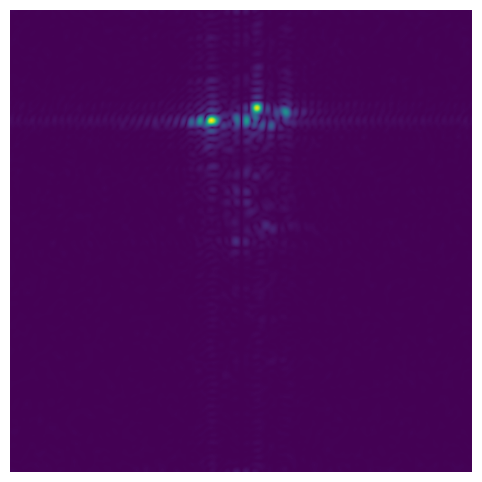

In [8]:
#magn = data_loader.get_magnitude(f"NewExp{exp_n}", 796)

# Load the magnitude from a png file
input_path = "/Users/hippolytehilgers/Downloads/RadarMagnitudes/map_533_5.png"
magn = cv2.imread(input_path, cv2.IMREAD_UNCHANGED)

# Delete last dimension
#magn = magn[:, :, 0]

# Show the magn as image (use viriidis colormap)
plt.figure(figsize=(10, 6))
plt.imshow(magn, cmap='viridis')
#plt.colorbar()
##plt.title('Magnitude Image')
plt.axis('off')
plt.show()

In [ ]:
#

In [5]:
all_train_losses = []
all_val_losses = []

exp = "Regression/BackToResNet4"
resultsPath = os.path.join("results", exp)
folds = [1,2,3,4,5,6,7,8] #list(range(1, 9))

for fold in folds :
    train_losses = np.load(os.path.join(resultsPath, f"fold{fold}", "train_losses.npy"))
    val_losses = np.load(os.path.join(resultsPath, f"fold{fold}", "val_losses.npy"))
    all_train_losses.append(train_losses)
    all_val_losses.append(val_losses)

# Crop fold 5
all_train_losses[4] = all_train_losses[4][:10]
all_val_losses[4] = all_val_losses[4][:10]

all_train_losses = np.array(all_train_losses)
all_val_losses = np.array(all_val_losses)

plot_multiple_learning_curves(all_train_losses, all_val_losses, resultsPath)


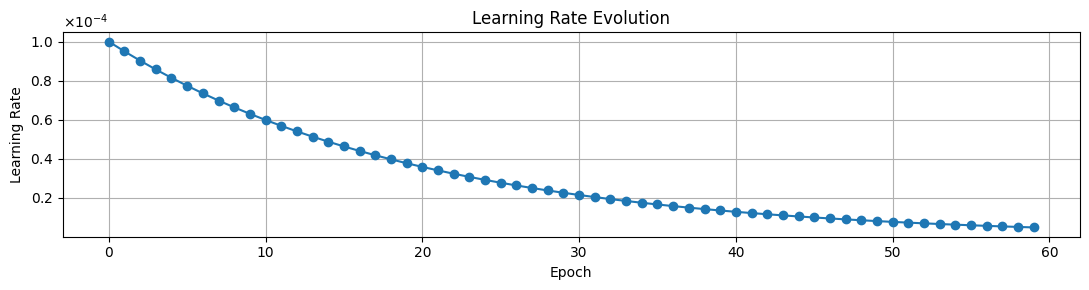

In [13]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


# Paramètres donnés
initial_lr = 0.0001
gamma = 0.95
epochs = 60

# Calcul du LR pour chaque epoch
lr_values = [initial_lr * (gamma ** epoch) for epoch in range(epochs)]

# Tracé
plt.figure(figsize=(11, 3))
plt.plot(range(epochs), lr_values, marker='o')
plt.title("Learning Rate Evolution")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.grid(True)
# Activation de la notation scientifique pour l'axe y
plt.gca().yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
plt.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
plt.tight_layout()
plt.show()


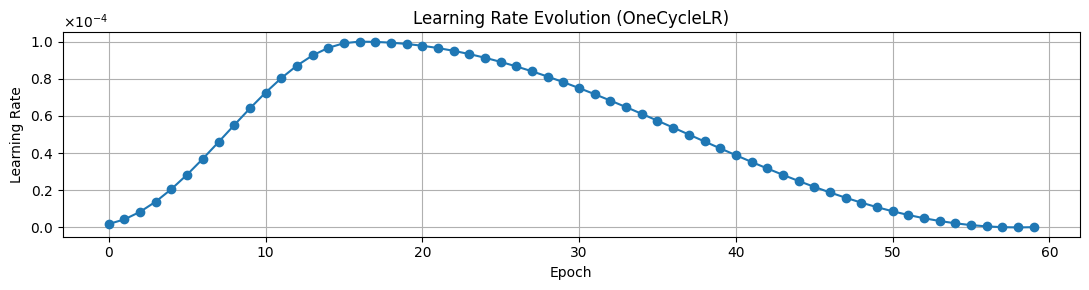

In [12]:
import torch
from torch.optim import Adam
from torch.optim.lr_scheduler import OneCycleLR
import torch.nn as nn

# Paramètres
epochs = 60
lr_start = 1e-6
max_lr = 1e-4
steps_per_epoch = 1  # pour visualisation simple : 1 update par epoch
total_steps = steps_per_epoch * epochs

# Dummy model
model = nn.Linear(10, 1)
optimizer = Adam(model.parameters(), lr=lr_start)

# Scheduler OneCycleLR
scheduler = OneCycleLR(
    optimizer,
    max_lr=max_lr,
    epochs=epochs,
    steps_per_epoch=steps_per_epoch,
    anneal_strategy="cos",
    div_factor=max_lr / lr_start  # pour respecter le lr de départ donné
)

# Simuler les updates
lr_values = []
for step in range(total_steps):
    scheduler.step()
    lr_values.append(optimizer.param_groups[0]['lr'])

# Tracer
plt.figure(figsize=(11, 3))
plt.plot(range(epochs), lr_values, marker='o')
plt.title("Learning Rate Evolution (OneCycleLR)")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.grid(True)
plt.gca().yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
plt.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
plt.tight_layout()
plt.show()


[0.91487748 0.4972283  0.41197977 0.33679678 0.29283687 0.2650475
 0.2460283  0.21594842 0.20983737 0.20746956 0.18319782 0.17444895
 0.16825659 0.14928372 0.15030345 0.13735609 0.14034688]
[ 0.26765674 16.78439501  0.94783504  1.08764251  0.95929663  0.42676876
  0.30261357  0.15722985  0.13444321  1.1790908   0.3015324   2.0443736
  0.14897253  0.5534622   0.33270048  0.15577121  0.18290603]


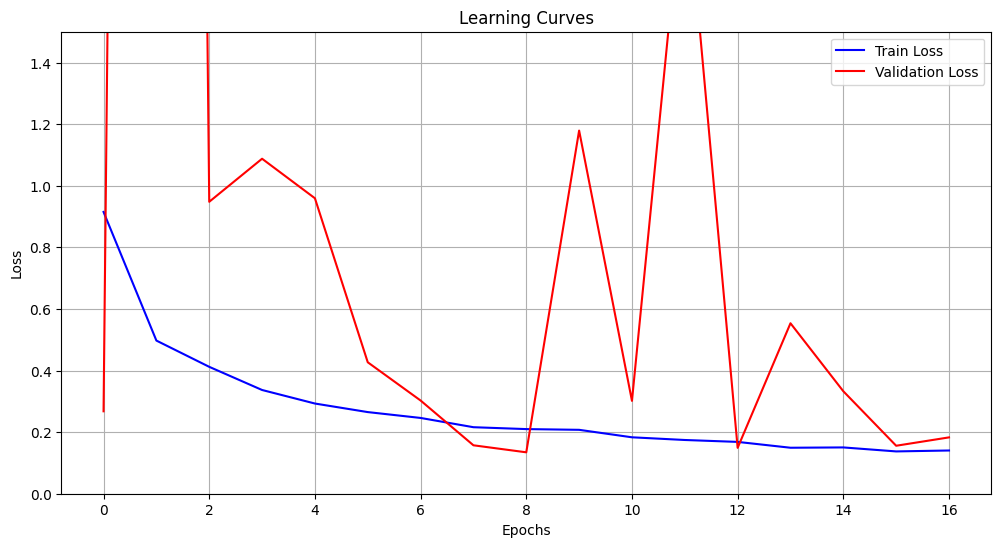

In [2]:
exp = "Regression/BackToResNet8/fold5"
resultsPath = os.path.join("results", exp)

# Load learning curves
train_losses = np.load(os.path.join(resultsPath, "train_losses.npy"))
val_losses = np.load(os.path.join(resultsPath, "val_losses.npy"))
print(train_losses)
print(val_losses)

# Crop to only 20 epochs
#train_losses = train_losses[:20]
#val_losses = val_losses[:20]

# Crop y-axis to [0, 0.5]


plot_learning_curves(train_losses, val_losses, resultsPath, file_name="learning_curves_0.5max")

In [ ]:
exp1 = "Regression/ResNet_Folds_debug18/fold5"
resultsPath1 = os.path.join("results", exp1)
train1 = np.load(os.path.join(resultsPath1, "train_losses.npy"))
val1 = np.load(os.path.join(resultsPath1, "val_losses.npy"))

exp2 = "Regression/ResNet_Folds_debug21/fold5"
resultsPath2 = os.path.join("results", exp2)
train2 = np.load(os.path.join(resultsPath2, "train_losses.npy"))
val2 = np.load(os.path.join(resultsPath2, "val_losses.npy"))

exp3 = "Regression/ResNet_Folds_debug22/fold5"
resultsPath3 = os.path.join("results", exp3)
train3 = np.load(os.path.join(resultsPath3, "train_losses.npy"))
val3 = np.load(os.path.join(resultsPath3, "val_losses.npy"))

labels = ("Simple CNN - 1 path", "Simple CNN - 2 path", "Simple CNN - 2 path + ATROU")

# Stack train and val losses
train_all = [train1, train2, train3]
val_all = [val1, val2, val3]

compare_multiple_learning_curves(train_all, val_all, labels, resultsPath3, title="Comparison of Learning Curves")

In [9]:
exp1 = "Regression/ResNet_Folds_debug25/fold5" # Nothing
resultsPath1 = os.path.join("results", exp1)
train1 = np.load(os.path.join(resultsPath1, "train_losses.npy"))
val1 = np.load(os.path.join(resultsPath1, "val_losses.npy"))

exp2 = "Regression/ResNet_Folds_debug24/fold5" # Only data augm
resultsPath2 = os.path.join("results", exp2)
train2 = np.load(os.path.join(resultsPath2, "train_losses.npy"))
val2 = np.load(os.path.join(resultsPath2, "val_losses.npy"))

exp3 = "Regression/ResNet_Folds_debug26/fold5" # Only prev frames
resultsPath3 = os.path.join("results", exp3)
train3 = np.load(os.path.join(resultsPath3, "train_losses.npy"))
val3 = np.load(os.path.join(resultsPath3, "val_losses.npy"))

exp4 = "Regression/ResNet_Folds_debug18/fold5" # Prev frames + data augm
resultsPath4 = os.path.join("results", exp4)
train4 = np.load(os.path.join(resultsPath4, "train_losses.npy"))
val4 = np.load(os.path.join(resultsPath4, "val_losses.npy"))

labels = ("/", "DA", "PV", "PV + DA")

# Stack train and val losses
train_all = [train1, train2, train3, train4]
val_all = [val1, val2, val3, val4]

compare_multiple_learning_curves(train_all, val_all, labels, resultsPath3, title="Comparison of Learning Curves")

In [ ]:
exp1 = "Regression/ResNet_Folds_debug21/fold5"
resultsPath1 = os.path.join("results", exp1)
train1 = np.load(os.path.join(resultsPath1, "train_losses.npy"))
val1 = np.load(os.path.join(resultsPath1, "val_losses.npy"))

exp2 = "Regression/ResNet_Folds_debug22/fold5"
resultsPath2 = os.path.join("results", exp2)
train2 = np.load(os.path.join(resultsPath2, "train_losses.npy"))
val2 = np.load(os.path.join(resultsPath2, "val_losses.npy"))


labels = ("2nd canal", "2nd canal + Atrou")
 
# Stack train and val losses
train_all = [train1, train2]
val_all = [val1, val2]

compare_multiple_learning_curves(train_all, val_all, labels, resultsPath2, title="Comparison of Learning Curves")

In [8]:
exp1 = "Regression/ResNet_Folds_debug26/fold5"
resultsPath1 = os.path.join("results", exp1)
train1 = np.load(os.path.join(resultsPath1, "train_losses.npy"))
val1 = np.load(os.path.join(resultsPath1, "val_losses.npy"))

exp2 = "Regression/ResNet_Folds_debug28/fold5"
resultsPath2 = os.path.join("results", exp2)
train2 = np.load(os.path.join(resultsPath2, "train_losses.npy"))
val2 = np.load(os.path.join(resultsPath2, "val_losses.npy"))


labels = ("-1", "-2")

# Stack train and val losses
train_all = [train1, train2]
val_all = [val1, val2]

compare_multiple_learning_curves(train_all, val_all, labels, resultsPath2, title="Comparison of Learning Curves")

In [7]:
exp1 = "Regression/ResNet_Homemade_1/fold2" # D=2
resultsPath1 = os.path.join("results", exp1)
train1 = np.load(os.path.join(resultsPath1, "train_losses.npy"))
val1 = np.load(os.path.join(resultsPath1, "val_losses.npy"))

exp2 = "Regression/ResNet_Homemade_2/fold2" # D=3
resultsPath2 = os.path.join("results", exp2)
train2 = np.load(os.path.join(resultsPath2, "train_losses.npy"))
val2 = np.load(os.path.join(resultsPath2, "val_losses.npy"))

exp3 = "Regression/ResNet_Homemade_3/fold2" # D=4
resultsPath3 = os.path.join("results", exp3)
train3 = np.load(os.path.join(resultsPath3, "train_losses.npy"))
val3 = np.load(os.path.join(resultsPath3, "val_losses.npy"))

exp4 = "Regression/ResNet_Homemade_4/fold2" # D=5
resultsPath4 = os.path.join("results", exp4)
train4 = np.load(os.path.join(resultsPath4, "train_losses.npy"))
val4 = np.load(os.path.join(resultsPath4, "val_losses.npy"))

labels = ("D=2", "D=3", "D=4", "D=5")

# Stack train and val losses
train_all = [train1, train2, train3, train4]
val_all = [val1, val2, val3, val4]

compare_multiple_learning_curves(train_all, val_all, labels, resultsPath4, max_y=0.5, title="Comparison of Learning Curves")

In [9]:
f = 2
exp1 = f"Regression/ResNet_Homemade_8/fold{f}" # N = 5
resultsPath1 = os.path.join("results", exp1)
train1 = np.load(os.path.join(resultsPath1, "train_losses.npy"))
val1 = np.load(os.path.join(resultsPath1, "val_losses.npy"))

exp2 = f"Regression/ResNet_Homemade_4/fold{f}" # N = 10
resultsPath2 = os.path.join("results", exp2)
train2 = np.load(os.path.join(resultsPath2, "train_losses.npy"))
val2 = np.load(os.path.join(resultsPath2, "val_losses.npy"))

exp3 = f"Regression/ResNet_Homemade_5/fold{f}" # N = 16
resultsPath3 = os.path.join("results", exp3)
train3 = np.load(os.path.join(resultsPath3, "train_losses.npy"))
val3 = np.load(os.path.join(resultsPath3, "val_losses.npy"))

exp4 = f"Regression/ResNet_Homemade_6/fold{f}" # N = 32
resultsPath4 = os.path.join("results", exp4)
train4 = np.load(os.path.join(resultsPath4, "train_losses.npy"))
val4 = np.load(os.path.join(resultsPath4, "val_losses.npy"))

exp5 = f"Regression/ResNet_Homemade_7/fold{f}" # N = 64
resultsPath5 = os.path.join("results", exp5)
train5 = np.load(os.path.join(resultsPath5, "train_losses.npy"))
val5 = np.load(os.path.join(resultsPath5, "val_losses.npy"))

labels = ("N=5", "N=10", "N=16", "N=32", "N=64")

# Stack train and val losses
train_all = [train1, train2, train3, train4, train5]
val_all = [val1, val2, val3, val4, val5]

compare_multiple_learning_curves(train_all, val_all, labels, resultsPath5, max_y=0.5, title="Comparison of Learning Curves")

In [6]:
exp1 = "Regression/ResNet_Homemade_9/fold5" # D=2
resultsPath1 = os.path.join("results", exp1)
train1 = np.load(os.path.join(resultsPath1, "train_losses.npy"))
val1 = np.load(os.path.join(resultsPath1, "val_losses.npy"))

exp2 = "Regression/ResNet_Homemade_10/fold5" # D=3
resultsPath2 = os.path.join("results", exp2)
train2 = np.load(os.path.join(resultsPath2, "train_losses.npy"))
val2 = np.load(os.path.join(resultsPath2, "val_losses.npy"))

exp3 = "Regression/ResNet_Homemade_11/fold5" # D=4
resultsPath3 = os.path.join("results", exp3)
train3 = np.load(os.path.join(resultsPath3, "train_losses.npy"))
val3 = np.load(os.path.join(resultsPath3, "val_losses.npy"))

exp4 = "Regression/ResNet_Homemade_12/fold5" # D=5
resultsPath4 = os.path.join("results", exp4)
train4 = np.load(os.path.join(resultsPath4, "train_losses.npy"))
val4 = np.load(os.path.join(resultsPath4, "val_losses.npy"))

labels = ("D=2", "D=3", "D=4", "D=5")

# Stack train and val losses
train_all = [train1, train2, train3, train4]
val_all = [val1, val2, val3, val4]

compare_multiple_learning_curves(train_all, val_all, labels, resultsPath4, max_y=0.75, title="Comparison of Learning Curves (Data augm)")

In [3]:
all_train_losses = []
all_val_losses = []

exp = "Regression/ResNet_Folds_Simple"
resultsPath = os.path.join("results", exp)
folds = [1,2,3,4,5,6,7,8] #list(range(1, 9))

for fold in folds :
    train_losses = np.load(os.path.join(resultsPath, f"fold{fold}", "train_losses.npy"))
    val_losses = np.load(os.path.join(resultsPath, f"fold{fold}", "val_losses.npy"))
    # Crop to 20 first epochs
    train_losses = train_losses[:20]
    val_losses = val_losses[:20]
    all_train_losses.append(train_losses)
    all_val_losses.append(val_losses)

# Set y-max
ymax = 0.5

all_train_losses = np.array(all_train_losses)
all_val_losses = np.array(all_val_losses)

plot_multiple_learning_curves(all_train_losses, all_val_losses, resultsPath, ymax)


In [5]:
# TO RUN BEFORE MEETING
f = 5
exp1 = f"Regression/ResNet_Homemade_13/fold{f}" # N = 5
resultsPath1 = os.path.join("results", exp1)
train1 = np.load(os.path.join(resultsPath1, "train_losses.npy"))
val1 = np.load(os.path.join(resultsPath1, "val_losses.npy"))

exp2 = f"Regression/ResNet_Homemade_12/fold{f}" # N = 10
resultsPath2 = os.path.join("results", exp2)
train2 = np.load(os.path.join(resultsPath2, "train_losses.npy"))
val2 = np.load(os.path.join(resultsPath2, "val_losses.npy"))

exp3 = f"Regression/ResNet_Homemade_14/fold{f}" # N = 16
resultsPath3 = os.path.join("results", exp3)
train3 = np.load(os.path.join(resultsPath3, "train_losses.npy"))
val3 = np.load(os.path.join(resultsPath3, "val_losses.npy"))

exp4 = f"Regression/ResNet_Homemade_15/fold{f}" # N = 32
resultsPath4 = os.path.join("results", exp4)
train4 = np.load(os.path.join(resultsPath4, "train_losses.npy"))
val4 = np.load(os.path.join(resultsPath4, "val_losses.npy"))

exp5 = f"Regression/ResNet_Homemade_16/fold{f}" # N = 64
resultsPath5 = os.path.join("results", exp5)
train5 = np.load(os.path.join(resultsPath5, "train_losses.npy"))
val5 = np.load(os.path.join(resultsPath5, "val_losses.npy"))

labels = ("N=5", "N=10", "N=16", "N=32", "N=64")

# Stack train and val losses
train_all = [train1, train2, train3, train4, train5]
val_all = [val1, val2, val3, val4, val5]

compare_multiple_learning_curves(train_all, val_all, labels, resultsPath5, max_y=0.5, title="Comparison of Learning Curves")